# 12 · Beyond EEG: fNIRS motor responses

**ROBT613 · Brain–Computer Interfaces** | Teaching session + independent lab

## Goal
Convert optical intensity to hemoglobin changes and compare a slow hemodynamic paradigm with electrophysiological BCI.

**Data:** Native MNE fNIRS motor dataset, participant 1

Run cells from top to bottom in a fresh CPU runtime. No previous notebook state is required.

## The question for today

A motor task changes measured light intensity rather than voltage. We follow that measurement through optical density and hemoglobin conversion, then compare its slow response with the EEG paradigms studied earlier.

### By the end you should be able to

- Explain intensity, optical density and relative hemoglobin concentration as distinct quantities.
- Describe the assumptions of the modified Beer–Lambert conversion.
- Recognize coupling and motion problems before interpreting averages.
- Relate hemodynamic latency to BCI decision timing.

**How to work:** predict each result before running it, execute one cell at a time, and write a short interpretation. The worked examples use small controlled arrays; the later walkthrough uses the dataset stated above. End-of-lesson exercises contain editable workspaces. A pending exercise message is expected until you complete its function.

## Setup
The first cell installs the tested core versions in Colab. Downloads are cached in `mne_data/`; a new Colab runtime loses that cache. A failed download is an error, never silently replaced by synthetic data.

In [1]:
# Colab: install before importing numerical libraries. Restart if pip requests it.
import sys, subprocess, os
if 'google.colab' in sys.modules:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q',
                           'mne==1.13.2', 'moabb==1.7.2'])
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import mne
from scipy import signal
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (balanced_accuracy_score, roc_auc_score,
                             ConfusionMatrixDisplay, classification_report)
from sklearn.model_selection import (GroupKFold, cross_validate, GridSearchCV)
SEED = 613
rng = np.random.default_rng(SEED)
DATA_ROOT = Path(os.environ.get('BCI_DATA', './mne_data')).resolve()
DATA_ROOT.mkdir(parents=True, exist_ok=True)
os.environ['MNE_DATA'] = str(DATA_ROOT)
mne.set_log_level('WARNING')
plt.rcParams.update({'figure.figsize': (9, 4), 'font.size': 11,
                     'axes.spines.top': False, 'axes.spines.right': False})
import importlib.metadata as metadata
print({p: metadata.version(p) for p in ['mne','moabb','numpy','scipy','scikit-learn']})
print('Dataset cache:', DATA_ROOT)

{'mne': '1.13.2', 'moabb': '1.7.2', 'numpy': '2.1.3', 'scipy': '1.15.3', 'scikit-learn': '1.6.1'}
Dataset cache: <dataset-cache>


### A different measurement of brain-related activity

Functional near-infrared spectroscopy measures light attenuation through tissue at multiple wavelengths. Changes in oxygenated and deoxygenated hemoglobin contribute to the measured intensity. The resulting hemodynamic response is indirect and slower than scalp electrical activity. A response after a motor task can therefore peak seconds after the task begins rather than hundreds of milliseconds after a flash.

The dataset here contains executed finger tapping, not imagined movement. This provides a concrete motor-response demonstration but cannot establish performance for an imagery BCI. Keep the task label visible in plots and reports.

### First transformation: intensity to optical density

Optical density expresses a relative change in intensity:

$$\Delta OD_\lambda(t)=-\ln\frac{I_\lambda(t)}{I_{\lambda,0}}.$$

If intensity decreases relative to the reference, optical density increases. Multiplying both intensity and its reference by the same positive scale does not change this ratio. This is useful, but it does not fix poor optode contact, saturated channels or motion-induced jumps. Inspect raw intensity before conversion and do not take logarithms of invalid nonpositive values.

### Second transformation: wavelength changes to chromophores

In a simplified two-wavelength model,

$$\begin{bmatrix}\Delta OD_{\lambda_1}\\\Delta OD_{\lambda_2}\end{bmatrix}=L\begin{bmatrix}\epsilon_{1,O}&\epsilon_{1,R}\\\epsilon_{2,O}&\epsilon_{2,R}\end{bmatrix}\begin{bmatrix}\Delta[HbO]\\\Delta[HbR]\end{bmatrix}.$$

The extinction coefficients describe wavelength-dependent absorption; the effective path length includes source-detector distance and a pathlength factor. Solving the linear system estimates relative concentration changes. The assumptions include approximate linearity and specified optical parameters. The result is not an absolute measurement of oxygenation at an anatomical point.

MNE performs this conversion with wavelength and optode metadata. The lesson states its pathlength factor explicitly. Changing that factor changes concentration scaling, so amplitudes from different parameter conventions are not directly comparable. The small numerical example below uses arbitrary coefficients only to teach the linear algebra; it is not a physical calibration table.

### Quality control and slow physiology

Scalp coupling index uses physiological consistency across wavelengths as a quality indicator. It supports a channel decision but is not proof that a task effect originates in cortex. Systemic blood flow, superficial tissue and motion can contribute. Short-separation measurements, when available, can help model superficial contributions; this lesson does not invent such channels when the recording does not provide them.

A low-pass filter retains the slow hemodynamic response, while a high-pass filter can reduce very slow drift. Filter choices must respect task duration and baseline length. Aggressive filtering may attenuate the very response of interest. Epochs need a longer post-event interval than P300 analysis, and adjacent task blocks may have overlapping hemodynamic responses.

Sensor-level HbO/HbR averages are the endpoint here. No optical tomography or EEG source imaging is included. A future fNIRS BCI would additionally require trial-level features, a training-only model and evaluation on independent runs or sessions.

### Worked example · intensity ratios

Convert three intensity ratios to optical density and predict the sign.

**Before running:** state your prediction and the assumption behind it.

In [2]:
demo_ratio=np.array([.8,1.,1.2])
print(pd.DataFrame({'Intensity ratio':demo_ratio,'Delta optical density':-np.log(demo_ratio)}))

   Intensity ratio  Delta optical density
0              0.8               0.223144
1              1.0              -0.000000
2              1.2              -0.182322


**Read the result.** A reduction in transmitted intensity corresponds to positive optical density change. Units and sign must be tracked across transformations.

**Pause and explain:** point to one computed value that supports this interpretation.

### Worked example · recover two concentrations

Solve a known two-component mixture using arbitrary coefficients.

**Before running:** state your prediction and the assumption behind it.

In [3]:
demo_E=np.array([[2.,1.],[1.,3.]])
demo_concentration=np.array([.4,-.2])
demo_od=demo_E@demo_concentration
demo_recovered=np.linalg.solve(demo_E,demo_od)
print('Recovered:',demo_recovered)
assert np.allclose(demo_recovered,demo_concentration)

Recovered: [ 0.4 -0.2]


**Read the result.** Two independent wavelength equations can separate two chromophore changes in this simplified model. Nearly dependent equations would make the estimate unstable.

**Pause and explain:** point to one computed value that supports this interpretation.

### Guided experiment · pathlength scaling

Solve the same optical-density observation using two assumed path lengths.

**Before running:** state your prediction and the assumption behind it.

In [4]:
for assumed_length in [1.,2.]:
    print('Length:',assumed_length,'Estimated change:',np.linalg.solve(assumed_length*demo_E,demo_od))

Length: 1.0 Estimated change: [ 0.4 -0.2]
Length: 2.0 Estimated change: [ 0.2 -0.1]


**Read the result.** Doubling the assumed effective path length halves the estimated concentration change. Report the convention with any amplitude claim.

**Pause and explain:** point to one computed value that supports this interpretation.

### Checkpoint · response timescale

Compare sample counts for a 0.8 s electrical-response interval and a 20 s hemodynamic interval at their respective illustrative sampling rates.

**Before running:** state your prediction and the assumption behind it.

In [5]:
print('EEG example:',round(.8*128),'samples')
print('fNIRS example:',round(20*10),'samples')
print('Observation durations:',.8,'s versus',20,'s')

EEG example: 102 samples
fNIRS example: 200 samples
Observation durations: 0.8 s versus 20 s


**Read the result.** Similar array lengths can represent very different physiological timescales. Interpret duration using the sampling rate, not the number of columns.

**Pause and explain:** point to one computed value that supports this interpretation.

## Apply the ideas to the complete pipeline

The next stages use the real recording or the explicitly labeled simulation described in the lesson. Keep preprocessing, feature extraction and evaluation decisions visible. Read each stage’s explanation before running its code.

### Method reference for the pipeline

fNIRS measures changes in detected near-infrared light related to absorption by oxygenated and deoxygenated hemoglobin. It does not measure neuronal voltage. Optical density is $\Delta OD_\lambda=-\ln[I_\lambda(t)/I_{\lambda,0}]$. The modified Beer–Lambert model is $\Delta OD_\lambda=\sum_j\epsilon_{\lambda j}\Delta c_j\,d\,DPF_\lambda$. With multiple wavelengths, solve this linear system for relative HbO/HbR concentration changes.

Source–detector distance and differential pathlength assumptions affect the estimate. Scalp blood flow, motion and systemic physiology can dominate. A low-frequency bandpass does not guarantee removal of superficial signals; short-separation regression is a separate technique. The hemodynamic response develops over seconds, so EEG timing and filtering choices cannot simply be reused.

This native MNE recording contains executed finger tapping and a control condition. It is not a motor-imagery BCI benchmark. The lesson supports the syllabus’s broader physiological-signal objective while keeping that distinction explicit.

## Load and convert intensity
Use documented annotation labels and retain source geometry. PPF is an explicit teaching assumption.

Inspect optical channels and source-detector distances before converting intensity to optical density. Coupling measures flag questionable channels, and Beer–Lambert conversion uses the recorded wavelengths and an explicit pathlength factor.

In [6]:
from mne.preprocessing.nirs import (optical_density,beer_lambert_law,
                                      scalp_coupling_index,source_detector_distances)
path=mne.datasets.fnirs_motor.data_path(path=DATA_ROOT,update_path=False)
intensity=mne.io.read_raw_nirx(path/'Participant-1',preload=True,verbose=False)
intensity.annotations.rename({'1.0':'Control','2.0':'Left','3.0':'Right'})
intensity.annotations.delete(np.where(intensity.annotations.description=='15.0')[0])
distance=source_detector_distances(intensity.info)
intensity.pick(np.where(distance>.01)[0])
od=optical_density(intensity)
sci=scalp_coupling_index(od)
od.info['bads']=[ch for ch,s in zip(od.ch_names,sci) if s<.5]
print('Low-coupling channels:',od.info['bads'])
haemo=beer_lambert_law(od,ppf=.1)
haemo.filter(.05,.7,h_trans_bandwidth=.2,l_trans_bandwidth=.02)

Low-coupling channels: []


<RawNIRX | Participant-1, 40 x 23239 (2974.6 s), ~7.1 MiB, data loaded>

### Inspect and interpret

Track which channels are retained at each step. State the measurement type before and after conversion, and avoid comparing concentration amplitudes across unspecified pathlength conventions.

**Record in your notes:** the relevant shape/count or metric, the units where applicable, and one limitation of the inference.

## Epoch the slow response
Use a long post-event interval and report how channel-quality choices affect interpretation.

Long epochs capture a slow motor-related hemodynamic response. The plotted average is across retained HbO channels, which is a descriptive summary that may hide spatial heterogeneity.

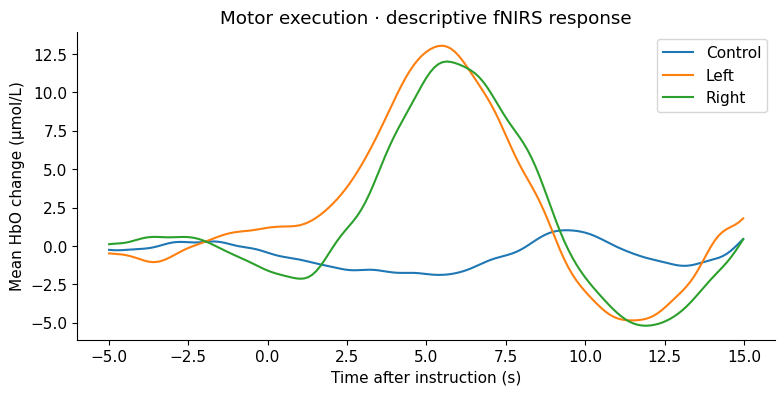

In [7]:
events,event_id=mne.events_from_annotations(haemo,event_id={'Control':1,'Left':2,'Right':3})
epochs=mne.Epochs(haemo,events,event_id,-5,15,baseline=(-5,0),preload=True)
fig,ax=plt.subplots()
for name in ['Control','Left','Right']:
    ev=epochs[name].average(picks='hbo')
    ax.plot(ev.times,ev.data.mean(0)*1e6,label=name)
ax.set(xlabel='Time after instruction (s)',ylabel='Mean HbO change (µmol/L)',title='Motor execution · descriptive fNIRS response')
ax.legend(); plt.show()

### Inspect and interpret

Compare task timing with response timing. Inspect HbR separately in the exercise, and explain why executed tapping is not evidence for imagery decoding.

**Record in your notes:** the relevant shape/count or metric, the units where applicable, and one limitation of the inference.

## Independent practice

Work through the tasks in order. Exercise 1 includes a small implementation check; passing it verifies the stated example, not every possible input. For the investigations, save a labeled figure or table and a short explanation. Use copies of data objects when changing preprocessing, and preserve any held-out evaluation partition.

**Submission:** your completed notebook, the requested outputs, and a brief exit-ticket response. The notebook runs before exercises are completed; “pending” means your work is still required.

### Exercise 1 · Optical-density function

Implement optical_density_change for strictly positive intensity and reference values.

In [8]:
def optical_density_change(intensity, reference):
    # TODO: natural logarithm of the relative intensity.
    return None

In [9]:
answer=optical_density_change(np.array([.5,1.,2.]),1.)
if answer is not None:
    assert np.allclose(answer,[np.log(2),0,-np.log(2)]); print('Optical-density checks passed.')
else: print('Exercise pending: implement optical_density_change.')

Exercise pending: implement optical_density_change.


**Your response:**

- Prediction or rationale: _write here_
- Evidence from your result: _write here_
- Interpretation and limitation: _write here_

### Exercise 2 · Channel audit

Inspect coupling values and optode distances. Explain the threshold and list retained channels rather than silently dropping them.

In [10]:
# Your investigation: add code here.
# Keep the original data and final test partition intact.

**Your response:**

- Prediction or rationale: _write here_
- Evidence from your result: _write here_
- Interpretation and limitation: _write here_

### Exercise 3 · Conversion sensitivity

Repeat conversion with another explicitly stated pathlength factor. Compare scale and waveform shape, explaining which changed.

In [11]:
# Your investigation: add code here.
# Keep the original data and final test partition intact.

**Your response:**

- Prediction or rationale: _write here_
- Evidence from your result: _write here_
- Interpretation and limitation: _write here_

### Exercise 4 · Filter interpretation

Plot the frequency response of the hemodynamic filter and relate it to task-block duration.

In [12]:
# Your investigation: add code here.
# Keep the original data and final test partition intact.

**Your response:**

- Prediction or rationale: _write here_
- Evidence from your result: _write here_
- Interpretation and limitation: _write here_

### Exercise 5 · BCI proposal

Design a trial-level feature and a grouped validation scheme for an fNIRS motor BCI. State the latency cost and the difference between executed and imagined movement.

In [13]:
# Your investigation: add code here.
# Keep the original data and final test partition intact.

**Your response:**

- Prediction or rationale: _write here_
- Evidence from your result: _write here_
- Interpretation and limitation: _write here_

### Exercise 6 · Exit ticket

Trace the units from measured intensity through optical density to relative HbO/HbR. Name two physiological confounds.

**Your response:**

- Prediction or rationale: _write here_
- Evidence from your result: _write here_
- Interpretation and limitation: _write here_

## Next steps and sources
[MNE fNIRS processing](https://mne.tools/stable/auto_tutorials/preprocessing/70_fnirs_processing.html).

Record package versions, subject/run IDs, preprocessing, split unit, random seed, and all exclusions with your results. Do not interpret a single participant as a population estimate.